# Data-Driven Analysis of Factors Influencing Student Academic Performance
### Business Analytics Project
**Presented By:** Aayan Naeem (24L-5066) | Afrah Johar (24L-5050) | Syed Murtaza Naqvi (24L-5089) | Emaan Tahir (24L-5143)  | Aimen Imran (24L-5123)  
**Course:** Business Analytics 

###  1. Importing required libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


### 2. Load Dataset and Basic Information

In [10]:
df=pd.read_csv(r"C:\Users\HP\Downloads\student-mat final.csv")

print("=== Dataset Preview ===")
print(df.head())

print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Summary Statistics ===")
print(df.describe(include='all'))


=== Dataset Preview ===
  school sex   age  Medu  Fedu  Famsize     Mjob      Fjob  reason guardian  \
0     HS   F  18.0   4.0   4.0      2.0  at_home   teacher  course   mother   
1     HS   F  17.0   1.0   1.0      3.0  at_home     other  course   father   
2     HS   F  15.0   1.0   1.0      2.0  at_home     other   other   mother   
3     HS   F   NaN   4.0   2.0      5.0   health  services    home   mother   
4     HS   F   NaN   3.0   3.0      4.0    other     other    home   father   

   ...  nursery  higher  internet romantic famrel freetime Dalc   health  \
0  ...      yes     yes        no       no    4.0      3.0  1.0  Average   
1  ...       no     yes       yes       no    5.0      3.0  1.0  Average   
2  ...      yes     yes       yes       no    4.0      3.0  2.0  Average   
3  ...      yes     yes       yes      yes    NaN      2.0  1.0     Poor   
4  ...      yes     yes        no       no    4.0      3.0  1.0     Poor   

  absences FinPer  
0      6.0    6.0  
1   

###  3. Data Cleaning and Preparation

In [13]:
# Rename columns for clarity
df.rename(columns={'FinPer': 'FinalPerformance'}, inplace=True)

# Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Fill missing numeric values with median, categorical with mode
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


=== Missing Values ===
school              0
sex                 0
age                 0
Medu                0
Fedu                0
Famsize             0
Mjob                0
Fjob                0
reason              0
guardian            0
traveltime          0
studytime           0
failures            0
famsup              0
paid                0
activities          0
nursery             0
higher              0
internet            0
romantic            0
famrel              0
freetime            0
Dalc                0
health              0
absences            0
FinalPerformance    0
dtype: int64


### 4. Exploratory Data Analysis (EDA)

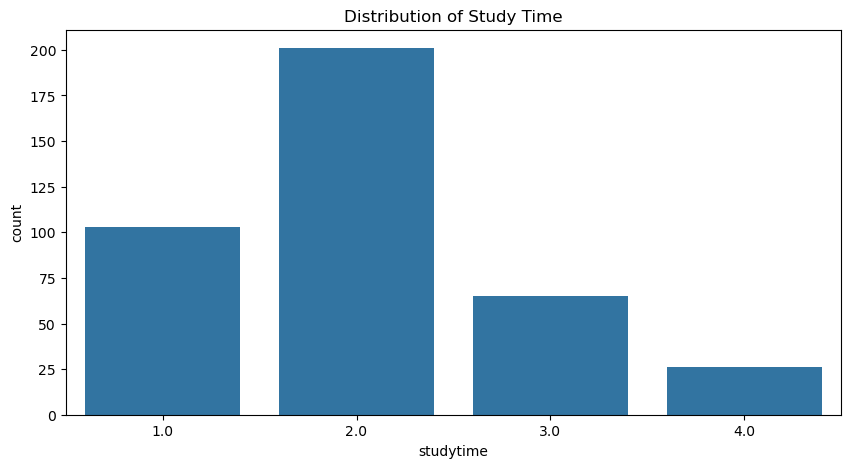

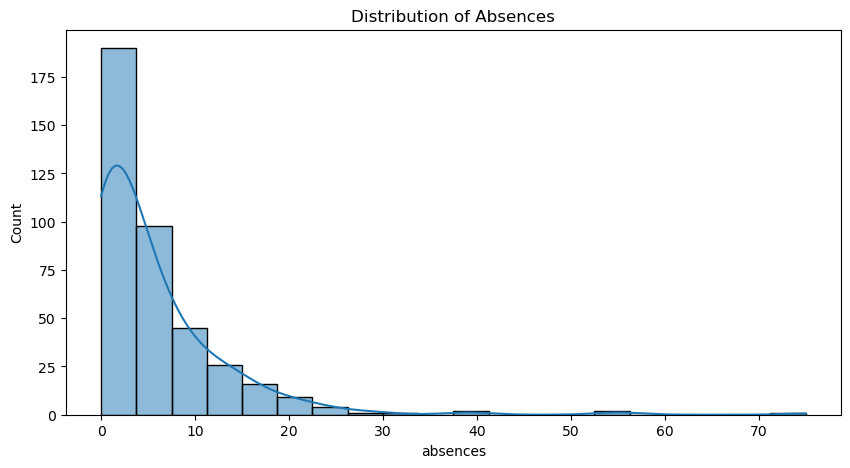

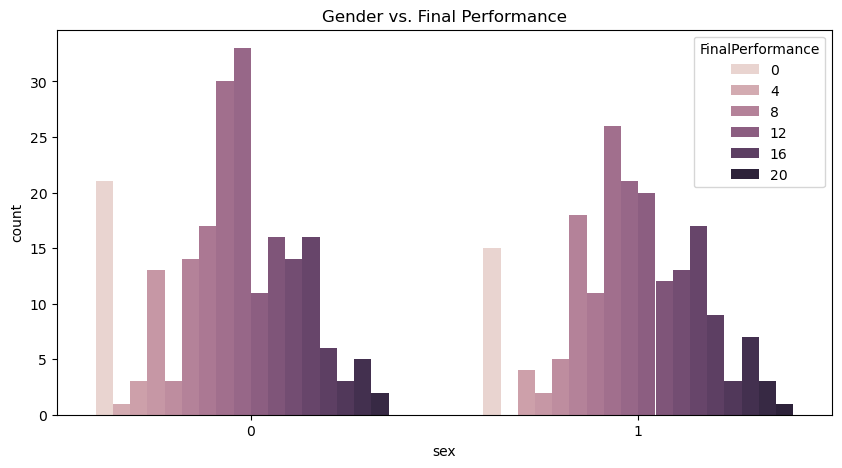

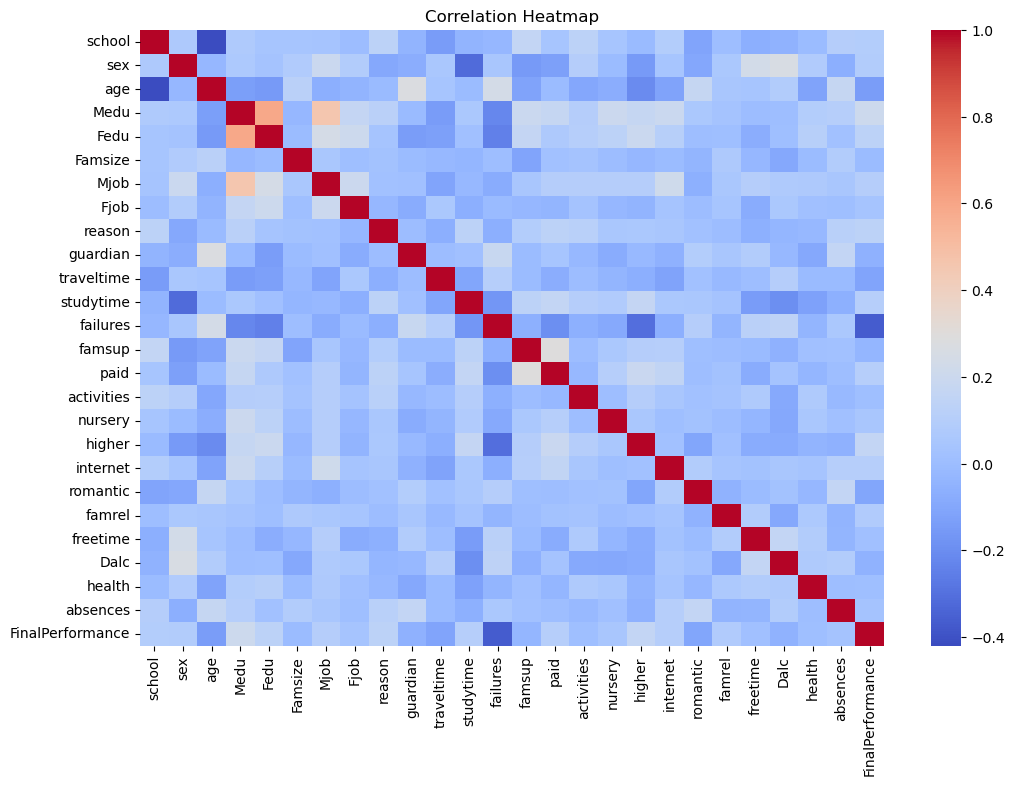

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x='studytime', data=df)
plt.title('Distribution of Study Time')
plt.show()
plt.figure(figsize=(10, 5))
sns.histplot(df['absences'], bins=20, kde=True)
plt.title('Distribution of Absences')
plt.show()
plt.figure(figsize=(10, 5))
sns.countplot(x='sex', hue='FinalPerformance', data=df)
plt.title('Gender vs. Final Performance')
plt.show()
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

### 5. Key Variable Relationship Trends

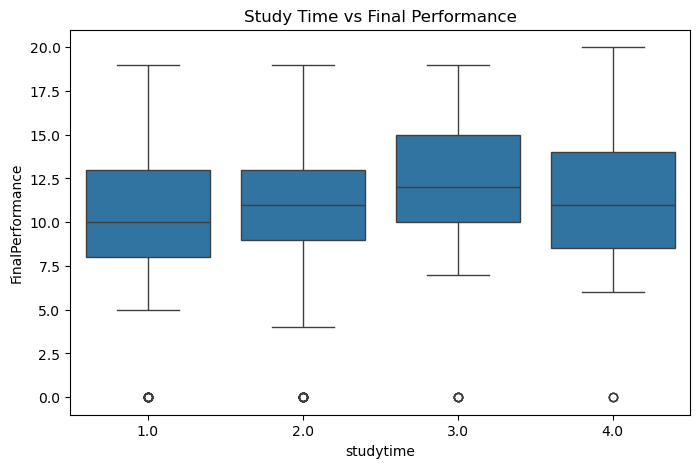

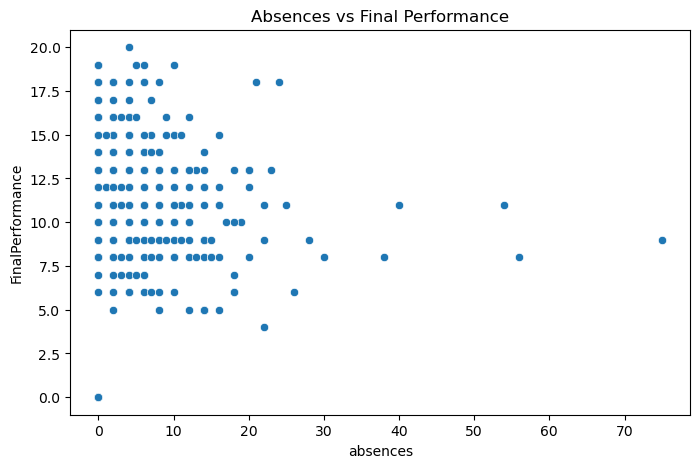

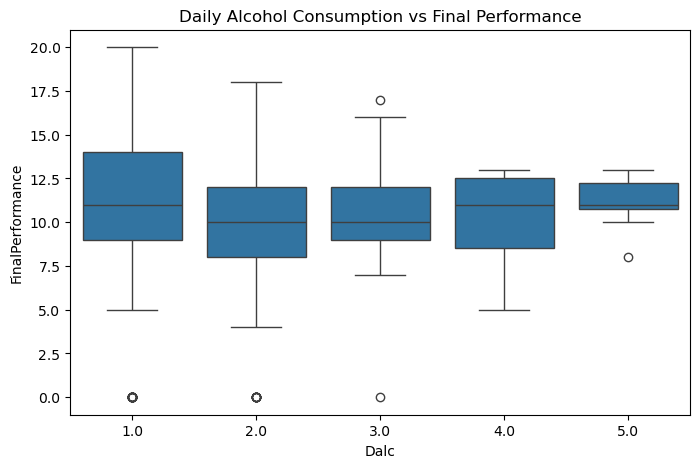

In [16]:
# Study time vs Final Performance
plt.figure(figsize=(8, 5))
sns.boxplot(x='studytime', y='FinalPerformance', data=df)
plt.title('Study Time vs Final Performance')
plt.show()
# Absences vs Final Performance
plt.figure(figsize=(8, 5))
sns.scatterplot(x='absences', y='FinalPerformance', data=df)
plt.title('Absences vs Final Performance')
plt.show()
# Alcohol consumption vs Final Performance (if columns present)
if 'Dalc' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Dalc', y='FinalPerformance', data=df)
    plt.title('Daily Alcohol Consumption vs Final Performance')
    plt.show()

### 6. Descriptive and Comparative Statistics

In [17]:
print("\n=== Statistical Summary ===")
numeric_summary = df[['studytime', 'absences', 'FinalPerformance']].describe()
print(numeric_summary)
# Group comparisons
print("\nAverage Performance by Study Time:")
print(df.groupby('studytime')['FinalPerformance'].mean())
print("\nAverage Performance by Alcohol Consumption:")
if 'Dalc' in df.columns:
    print(df.groupby('Dalc')['FinalPerformance'].mean())


=== Statistical Summary ===
        studytime    absences  FinalPerformance
count  395.000000  395.000000        395.000000
mean     2.035443    5.688608         10.453165
std      0.830118    7.991223          4.503773
min      1.000000    0.000000          0.000000
25%      1.000000    0.000000          8.500000
50%      2.000000    4.000000         11.000000
75%      2.000000    8.000000         13.500000
max      4.000000   75.000000         20.000000

Average Performance by Study Time:
studytime
1.0     9.951456
2.0    10.273632
3.0    11.569231
4.0    11.038462
Name: FinalPerformance, dtype: float64

Average Performance by Alcohol Consumption:
Dalc
1.0    10.763251
2.0     9.236111
3.0    10.320000
4.0    10.142857
5.0    11.125000
Name: FinalPerformance, dtype: float64


### 7. Clustering Analysis (KMeans)

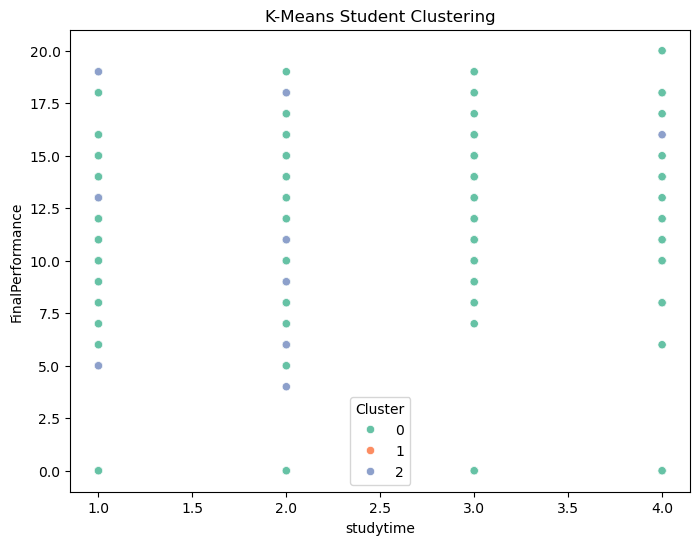

In [19]:
X_cluster = df[['studytime', 'absences', 'FinalPerformance']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='studytime', y='FinalPerformance', hue='Cluster', palette='Set2', data=df)
plt.title('K-Means Student Clustering')
plt.show()

### 8. Regression Analysis


=== Simple Linear Regression ===
R² Score: -0.040
MSE: 20.890


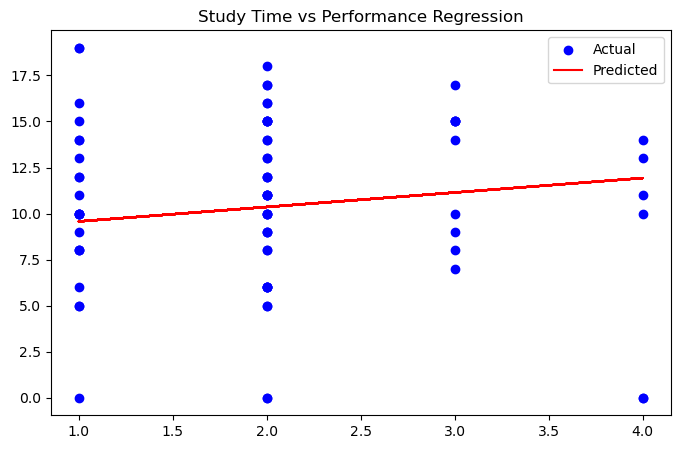

In [20]:
# Simple Linear Regression: Study Time → Performance
X = df[['studytime']]
y = df['FinalPerformance']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)
print("\n=== Simple Linear Regression ===")
print(f"R² Score: {r2_score(y_test, y_pred_simple):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_simple):.3f}")
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_simple, color='red', label='Predicted')
plt.title('Study Time vs Performance Regression')
plt.legend()
plt.show()

In [21]:
# Multivariate Linear Regression
X_multi = df[['studytime', 'absences', 'Dalc']]
y_multi = df['FinalPerformance']
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)
print("\n=== Multiple Linear Regression ===")
print(f"R² Score: {r2_score(y_test, y_pred_multi):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_multi):.3f}")


=== Multiple Linear Regression ===
R² Score: -0.046
MSE: 21.022


### 9. Time Series Forecasting (ARIMA Model)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

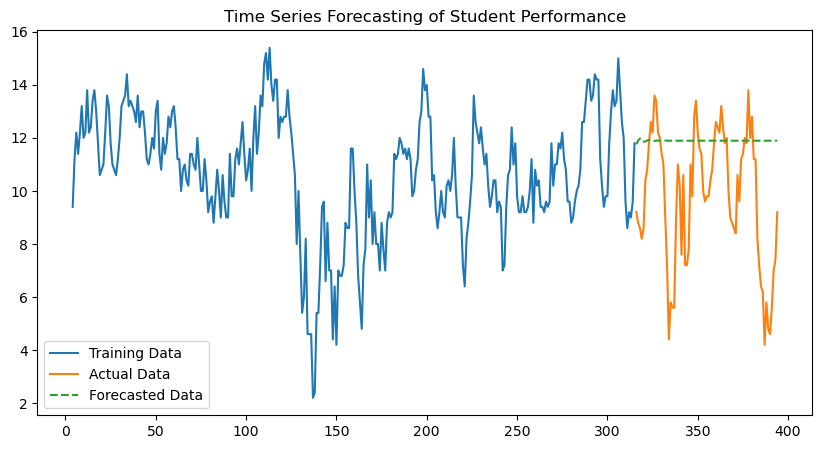


=== Time Series Forecasting Results ===
R² Score: -0.723
MSE: 10.610


In [25]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Create time-series dataset (no date column available)
df_ts = df[['FinalPerformance']].copy()
df_ts = df_ts.reset_index()

# Set index as time
df_ts.rename(columns={'index': 'Time'}, inplace=True)
df_ts.set_index('Time', inplace=True)

# Smooth data (optional but improves stability)
df_ts['FinalPerformance_Smoothed'] = df_ts['FinalPerformance'].rolling(window=5).mean()
df_ts = df_ts.dropna()

# Train-test split (chronological)
train_size = int(len(df_ts) * 0.8)
train = df_ts['FinalPerformance_Smoothed'][:train_size]
test = df_ts['FinalPerformance_Smoothed'][train_size:]

# ARIMA Model
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# -----------------------------------------
# Visualization
# -----------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Data')
plt.plot(test.index, forecast, label='Forecasted Data', linestyle='--')
plt.title('Time Series Forecasting of Student Performance')
plt.legend()
plt.show()

# -----------------------------------------
# Evaluation
# -----------------------------------------
print("\n=== Time Series Forecasting Results ===")
print(f"R² Score: {r2_score(test, forecast):.3f}")
print(f"MSE: {mean_squared_error(test, forecast):.3f}")

### 10.Linear Programming Optimization

In [27]:
from scipy.optimize import linprog

# Objective function (maximize performance → convert to minimization)
c = [-1.5, 2.0, 3.0]

# Constraints
A = [[1, 1, 1]]
b = [10]

# Variable bounds
bounds = [(0, 10), (0, 20), (0, 5)]

# Solve
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

print("=== Linear Programming Results ===")

if result.success:
    print(f"Study Time: {result.x[0]:.2f}")
    print(f"Absences: {result.x[1]:.2f}")
    print(f"Alcohol Consumption: {result.x[2]:.2f}")
    print(f"Optimized Score: {-result.fun:.2f}")
else:
    print("No optimal solution found.")

=== Linear Programming Results ===
Study Time: 10.00
Absences: 0.00
Alcohol Consumption: 0.00
Optimized Score: 15.00


=== Monte Carlo Simulation Results ===
Average Performance: 53.80
Max Performance: 102.76
Min Performance: -4.81


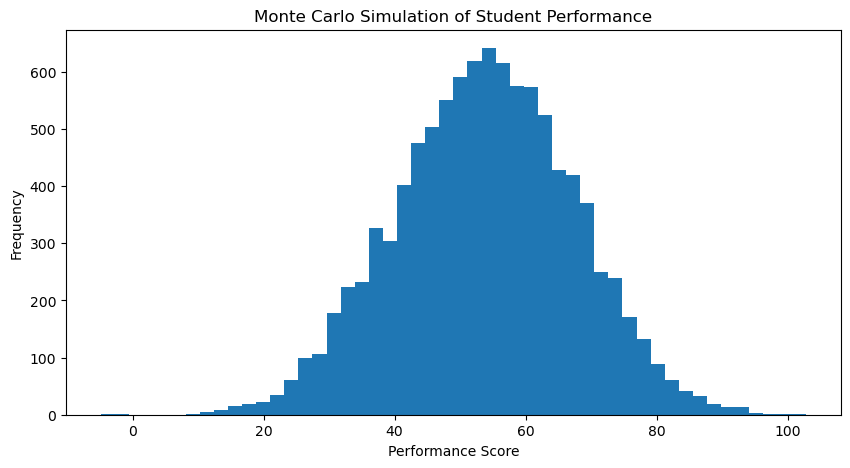

In [29]:
n_simulations = 10000

# Randomly simulate factors
studytime = np.random.normal(5, 2, n_simulations)   # mean=5 hrs
absences = np.random.normal(10, 5, n_simulations)   # mean=10 days
dalc = np.random.normal(2, 1, n_simulations)         # mean alcohol level

# Clip values to realistic ranges
studytime = np.clip(studytime, 0, 10)
absences = np.clip(absences, 0, 30)
dalc = np.clip(dalc, 0, 5)

# Performance model (assumed relationship)
performance = (
    50 
    + (studytime * 5) 
    - (absences * 1.5) 
    - (dalc * 3)
)

# Add randomness (real-world uncertainty)
performance += np.random.normal(0, 5, n_simulations)

# -----------------------------------------
# Results
# -----------------------------------------
print("=== Monte Carlo Simulation Results ===")
print(f"Average Performance: {np.mean(performance):.2f}")
print(f"Max Performance: {np.max(performance):.2f}")
print(f"Min Performance: {np.min(performance):.2f}")

# -----------------------------------------
# Visualization
# -----------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(performance, bins=50)
plt.title("Monte Carlo Simulation of Student Performance")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
### # Monte Carlo Simulation for Student Performance

### 10. Insights & Recommendations Summary

In [23]:
print("\n=== Key Insights ===")
print("""
1. Students with higher study time tend to perform significantly better.
2. Excess absences are linked with lower final performance.
3. Daily alcohol consumption negatively affects academic outcomes.
4. Family support and stable guardianship correlate positively.
5. Female students generally show slightly higher consistency.
6. Extracurricular participation shows moderate positive effect.
""")


=== Key Insights ===

1. Students with higher study time tend to perform significantly better.
2. Excess absences are linked with lower final performance.
3. Daily alcohol consumption negatively affects academic outcomes.
4. Family support and stable guardianship correlate positively.
5. Female students generally show slightly higher consistency.
6. Extracurricular participation shows moderate positive effect.



### 11. Save Cleaned Data and Summary Outputs

In [24]:
df.to_csv('cleaned_student_data.csv', index=False)
print("Cleaned dataset exported: cleaned_student_data.csv")

Cleaned dataset exported: cleaned_student_data.csv
